## Setting up environment for Colab

In [ ]:
from google.colab import drive

drive.mount("/content/drive")


Mounted at /content/drive


In [ ]:
import sys
from google.colab import userdata

config_path = userdata.get('CONFIG_PATH')

sys.path.append(config_path)

from config import BASE_PATH, DATA_PATH, SRC_PATH, SAVED_CHECKPOINTS_PATH

## Week 3 Session 3 — Interpretability & Explainability in Misinformation Detection

### Learning Objectives

In this session, we will explore how to **understand and explain** misinformation detection model decisions. Understanding *why* a model classifies an article as fake or real is crucial for:

- **Trust & Transparency**: Users need to understand AI decisions affecting content moderation
- **Debugging**: Identifying when models rely on spurious correlations
- **Regulatory Compliance**: Many jurisdictions require explainable AI for high-stakes decisions
- **Bias Detection**: Understanding which features drive predictions across different groups

---

### What You'll Implement

1. **XGBoost Feature Importance Analysis:**  
   - Extract and visualize built-in feature importance scores
   - Understand which linguistic and TF-IDF features matter most
   - Analyze top predictive features for fake vs. real news

2. **SHAP (SHapley Additive exPlanations) Library:**  
   - Use the SHAP library for individual prediction explanations
   - Generate summary plots showing feature impact across the dataset
   - Create waterfall plots for specific examples
   - Explore partial dependence and feature interactions

3. **Custom SHAP Implementation:**  
   - Implement SHAP values from scratch using sampling-based approximation
   - Understand the mathematical foundation of Shapley values
   - Compare custom implementation with library results
   - Build intuition for how SHAP actually works

---

### Why This Matters

Misinformation detection systems impact public discourse and democratic processes. When these systems flag content as "fake news," the decisions must be:
- **Transparent**: Stakeholders can understand the reasoning
- **Accountable**: Decisions can be reviewed and challenged
- **Debuggable**: Problems can be identified and fixed
- **Fair**: Not systematically biased against certain viewpoints

**Interpretability** helps achieve all these goals by making the "black box" transparent.

---

**Outcome**: By the end, you'll have multiple tools to explain misinformation detection decisions and understand the key insights for building trustworthy AI systems.


## Libraries & Setup

For this interpretability session, we'll use:

- **pandas** & **numpy** — Data manipulation and numerical operations
- **scikit-learn** — Model training, TF-IDF, and evaluation metrics  
- **xgboost** — Our main misinformation detection model
- **shap** — Industry-standard explainability library
- **matplotlib** & **seaborn** — Visualization of explanations and feature importance
- **tqdm** — Progress bars for computation-heavy SHAP calculations

We'll also implement custom SHAP calculations to understand the underlying mathematics.


In [ ]:
!pip install pandas numpy scikit-learn xgboost shap matplotlib seaborn tqdm


In [ ]:
!pip install {SRC_PATH}

Processing ./drive/MyDrive/MASAID/AI_Project_Course/Misinformation/repo/src
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.6/176.6 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 23.1 MB/s eta 0:00:00
  Created wheel for misinformation_detection: filename=misinformation_detection-1.0.0-py3-none-any.whl size=20155 sha256=200fc46fe1c0b60fc5214982be4114e4ee870c956b581e9059fe1688866d2532
  Stored in directory: /tmp/pip-ephem-wheel-cache-djd8j81f/wheels/46/67/19/6967c24d7ffe355b16d9bd45b2a6576a3fa548c7b58c981aee
Successfully built misinformation_detection


In [ ]:
# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings("ignore")

# Essential libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier

# Interpretability
import shap

print("All libraries imported successfully!")
print("Ready to explore misinformation detection interpretability")


All libraries imported successfully!
Ready to explore misinformation detection interpretability


## Load and Prepare FakeNewsNet Data

We'll reuse the data preparation pipeline from previous FNN sessions to ensure consistency. This includes:
- Loading the cleaned and lemmatized FakeNewsNet dataset
- Extracting structured linguistic features (word count, readability, etc.)
- Creating TF-IDF features from lemmatized text
- Combining all features into a unified dataset for interpretability analysis


In [ ]:
from misinformation_detection.data import prepare_text_structured_features_full
from pathlib import Path

X_train_combined, X_test_combined, X_structured_train_full, X_structured_test_full, y_train, y_test, vectorizer = prepare_text_structured_features_full(
    DATA_PATH / Path("processed/fnn_lemmatized.csv")
)

## XGBoost Model loading

Let's load our trained XGBoost model from earlier

XGBoost is an excellent choice for interpretability studies because:
- **Built-in feature importance**: Provides baseline feature rankings
- **Tree-based**: Compatible with SHAP's TreeExplainer for fast explanations
- **High performance**: Strong baseline accuracy for meaningful explanations
- **Feature interactions**: Can capture complex patterns in misinformation


Model loaded from /content/drive/MyDrive/MASAID/AI_Project_Course/Misinformation/repo/data/saved_checkpoints/xgboost_model.joblib
Accuracy: 0.8233, Precision: 0.7641, Recall: 0.3385, F1-score: 0.4692


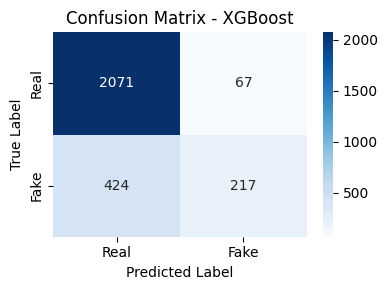

(0.8233177401943145,
 0.7640845070422535,
 0.33853354134165364,
 0.46918918918918917)

In [ ]:

from misinformation_detection.models import XGBoostModel

# Convert labels to numeric: real=0, fake=1
y_train_encoded = y_train.map({"real": 0, "fake": 1})
y_test_encoded = y_test.map({"real": 0, "fake": 1})

# 1. Initialize and train
xgb_clf = XGBoostModel(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    use_label_encoder=False,
    eval_metric="logloss",
    random_state=42
)

xgb_clf.load_model(SAVED_CHECKPOINTS_PATH / Path("xgboost_model.joblib"))

xgb_clf.evaluate(X_test_combined, y_test_encoded)

## Part 1: XGBoost Feature Importance Analysis

XGBoost provides built-in **feature importance scores** that measure how much each feature contributes to the model's decision-making process. These importance scores are calculated based on:

- **Gain**: Average improvement in accuracy when the feature is used for splits
- **Cover**: Average coverage of samples when the feature is used
- **Frequency**: How often the feature is used in tree splits

Understanding which features are most important helps us:
- **Validate model logic**: Are the important features sensible for misinformation detection?
- **Identify bias risks**: Are problematic features (like source names) overly influential?
- **Guide feature engineering**: Which types of features should we focus on?
- **Debug model behavior**: Why might the model be making certain mistakes?


In [ ]:
import pandas as pd

# === Extract and analyze feature importance ===
print("Analyzing XGBoost Feature Importance...")

# Get feature importance scores
feature_names = X_train_combined.columns.tolist()
feature_importance = xgb_clf.model.feature_importances_

# Create importance DataFrame
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

# Separate TF-IDF and structured features
tfidf_features = [f for f in feature_names if f in vectorizer.get_feature_names_out()]
struct_features = [f for f in feature_names if f in X_structured_train_full.columns]

importance_tfidf = importance_df[importance_df['feature'].isin(tfidf_features)].head(10)
importance_struct = importance_df[importance_df['feature'].isin(struct_features)].head(10)

print(f"\nTop 10 Most Important Features Overall:")
print(importance_df.head(10).to_string(index=False))

print(f"\nTop 10 TF-IDF Features:")
print(importance_tfidf.to_string(index=False))

print(f"\nTop 10 Structured Features:")
print(importance_struct.to_string(index=False))


Analyzing XGBoost Feature Importance...

Top 10 Most Important Features Overall:
               feature  importance
                source    0.105449
     source_people.com    0.033691
source_radaronline.com    0.030023
                season    0.023392
          source_Other    0.023243
  source_inquisitr.com    0.019766
               episode    0.017298
            verb_ratio    0.016422
          relationship    0.014709
            kardashian    0.012905

Top 10 TF-IDF Features:
     feature  importance
      source    0.105449
      season    0.023392
     episode    0.017298
relationship    0.014709
  kardashian    0.012905
       black    0.012414
   instagram    0.011871
      shared    0.010107
        2018    0.009939
          ha    0.009299

Top 10 Structured Features:
               feature  importance
     source_people.com    0.033691
source_radaronline.com    0.030023
          source_Other    0.023243
  source_inquisitr.com    0.019766
            verb_ratio    0.01

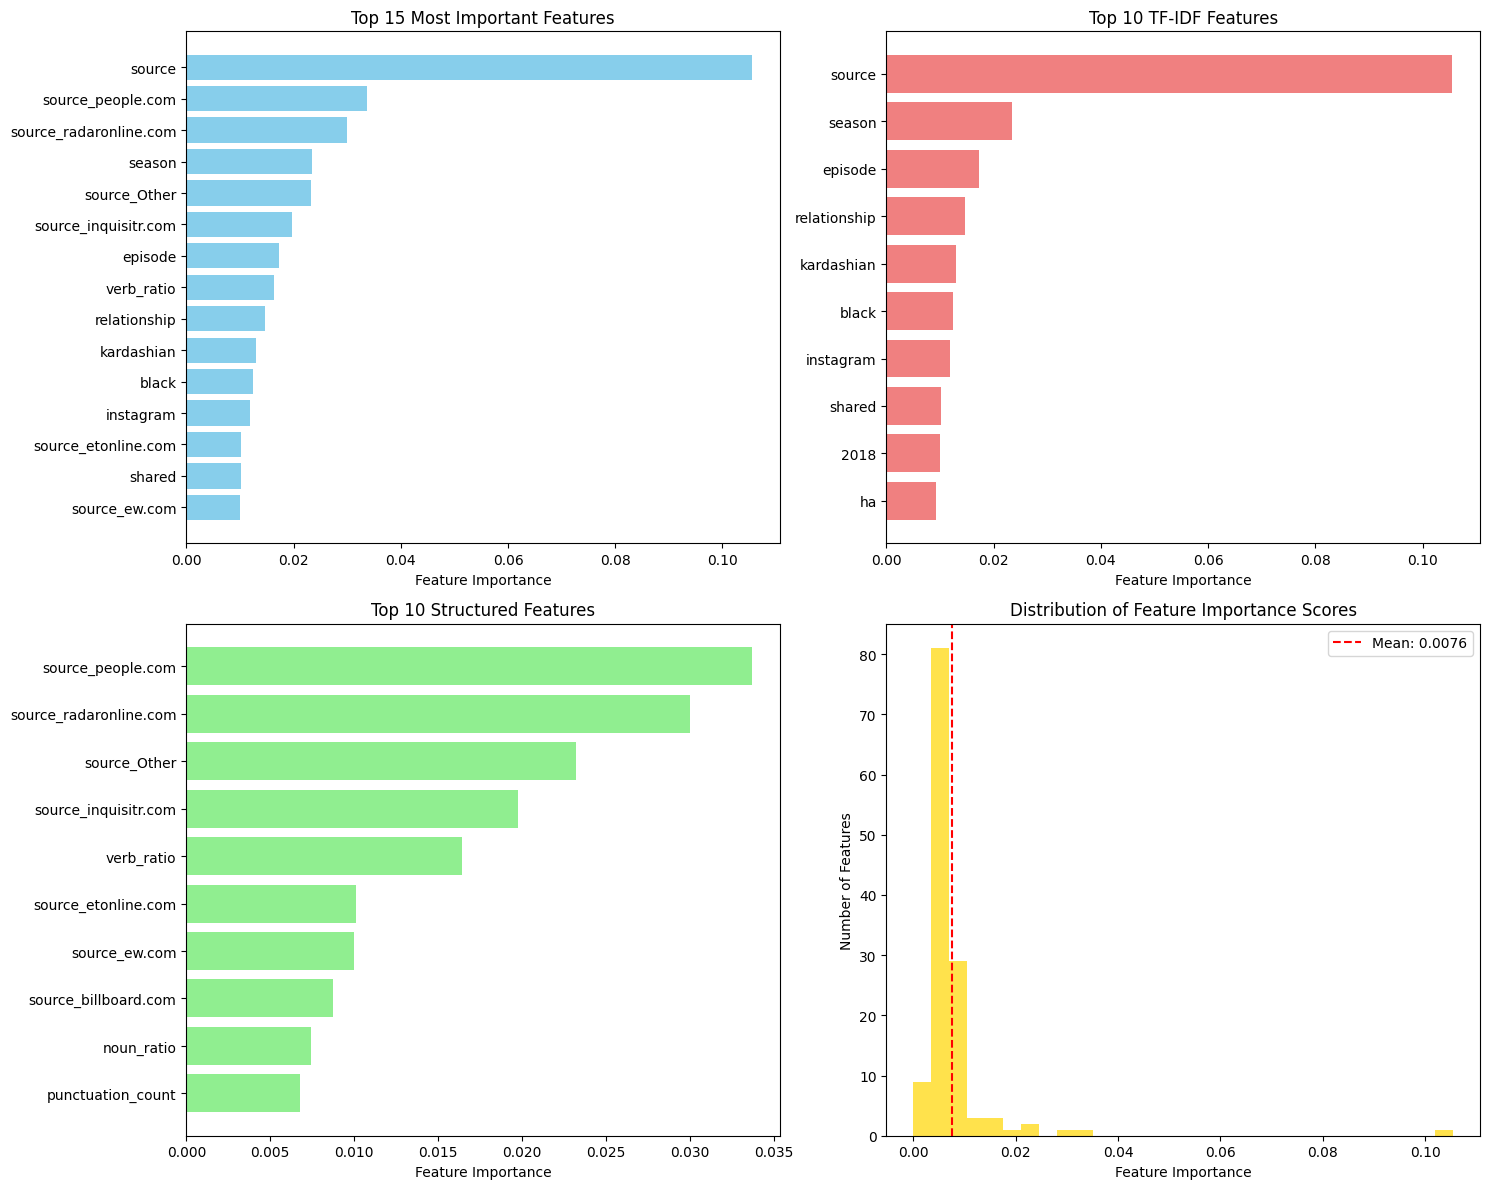


Feature Importance Insights:
   • Total features: 131
   • Features with importance > 0.01: 14
   • Top 10 features account for: 29.69% of total importance
   • TF-IDF vs. Structured importance ratio: 0.227 : 0.166
   • Source features total importance: 0.1529 (potential bias indicator)


In [ ]:
import matplotlib.pyplot as plt

# === Visualize feature importance ===
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Overall top features
top_features = importance_df.head(15)
axes[0, 0].barh(range(len(top_features)), top_features['importance'], color='skyblue')
axes[0, 0].set_yticks(range(len(top_features)))
axes[0, 0].set_yticklabels(top_features['feature'])
axes[0, 0].set_xlabel('Feature Importance')
axes[0, 0].set_title('Top 15 Most Important Features')
axes[0, 0].invert_yaxis()

# Top TF-IDF features
axes[0, 1].barh(range(len(importance_tfidf)), importance_tfidf['importance'], color='lightcoral')
axes[0, 1].set_yticks(range(len(importance_tfidf)))
axes[0, 1].set_yticklabels(importance_tfidf['feature'])
axes[0, 1].set_xlabel('Feature Importance')
axes[0, 1].set_title('Top 10 TF-IDF Features')
axes[0, 1].invert_yaxis()

# Top structured features
axes[1, 0].barh(range(len(importance_struct)), importance_struct['importance'], color='lightgreen')
axes[1, 0].set_yticks(range(len(importance_struct)))
axes[1, 0].set_yticklabels(importance_struct['feature'])
axes[1, 0].set_xlabel('Feature Importance')
axes[1, 0].set_title('Top 10 Structured Features')
axes[1, 0].invert_yaxis()

# Feature importance distribution
axes[1, 1].hist(feature_importance, bins=30, alpha=0.7, color='gold')
axes[1, 1].set_xlabel('Feature Importance')
axes[1, 1].set_ylabel('Number of Features')
axes[1, 1].set_title('Distribution of Feature Importance Scores')
axes[1, 1].axvline(feature_importance.mean(), color='red', linestyle='--', label=f'Mean: {feature_importance.mean():.4f}')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

# === Analyze feature importance insights ===
print(f"\nFeature Importance Insights:")
print(f"   • Total features: {len(feature_names)}")
print(f"   • Features with importance > 0.01: {(feature_importance > 0.01).sum()}")
print(f"   • Top 10 features account for: {importance_df.head(10)['importance'].sum():.2%} of total importance")
print(f"   • TF-IDF vs. Structured importance ratio: {importance_tfidf['importance'].sum():.3f} : {importance_struct['importance'].sum():.3f}")

# Check for potential bias indicators
source_features = [f for f in feature_names if 'source_' in f]
if source_features:
    source_importance = importance_df[importance_df['feature'].isin(source_features)]['importance'].sum()
    print(f"   • Source features total importance: {source_importance:.4f} (potential bias indicator)")


## Part 2: SHAP (SHapley Additive exPlanations) Analysis

While feature importance tells us which features are generally important, **SHAP values** tell us:
- **How much each feature contributes** to individual predictions
- **Which direction** each feature pushes the prediction (toward fake or real)
- **How feature contributions vary** across different examples
- **Feature interactions** and their combined effects

SHAP is based on **Shapley values** from game theory, which provide a mathematically principled way to attribute model predictions to input features.

### SHAP Key Concepts:
- **Additive**: SHAP values sum to the difference between prediction and average prediction
- **Fair**: Each feature gets credit proportional to its marginal contribution
- **Individual**: Every prediction gets its own explanation
- **Consistent**: More impactful features get higher SHAP values


In [ ]:
# === Initialize SHAP explainer ===
print("Initializing SHAP TreeExplainer...")

# TreeExplainer is optimized for tree-based models like XGBoost
explainer = shap.TreeExplainer(xgb_clf.model)

# Calculate SHAP values for test set (subset for computational efficiency)
shap_sample_size = min(500, len(X_test_combined))
X_test_sample = X_test_combined.sample(n=shap_sample_size, random_state=42)
y_test_sample = y_test.loc[X_test_sample.index]

print(f"Calculating SHAP values for {shap_sample_size} test samples...")
shap_values = explainer.shap_values(X_test_sample)

print(f"SHAP values calculated!")
print(f"SHAP values shape: {shap_values.shape}")
print(f"Base value (average prediction): {explainer.expected_value:.4f}")


Initializing SHAP TreeExplainer...
Calculating SHAP values for 500 test samples...
SHAP values calculated!
SHAP values shape: (500, 131)
Base value (average prediction): -1.2337


Creating SHAP summary plot...


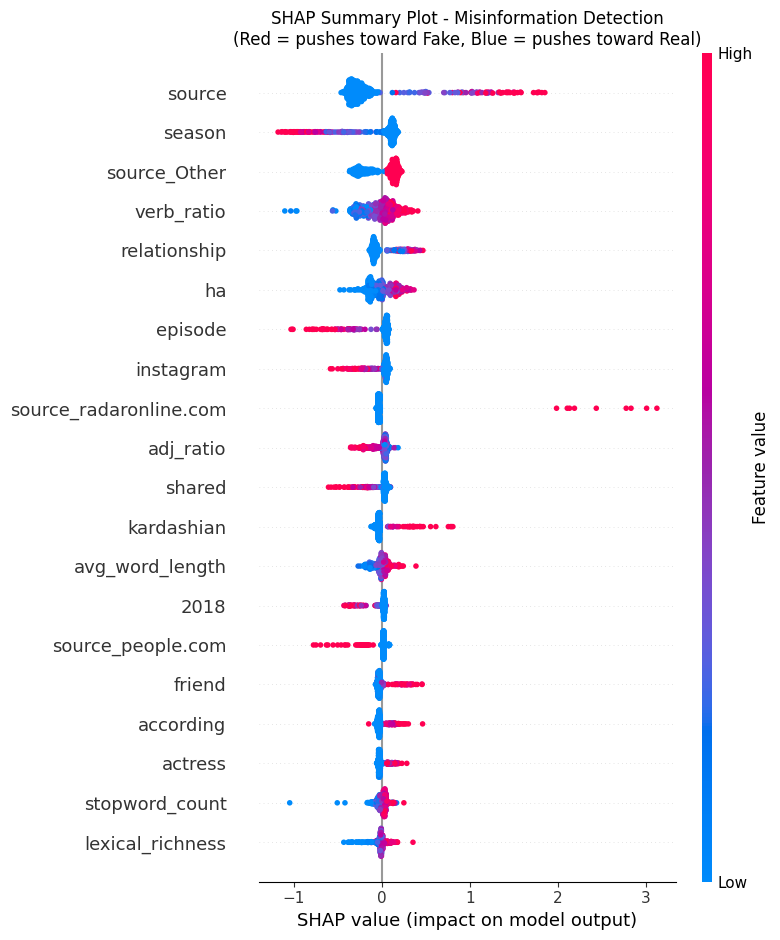


How to read this plot:
   • Y-axis: Features ranked by importance
   • X-axis: SHAP value (impact on model output)
   • Color: Feature value (red=high, blue=low)
   • Dots: Individual predictions
   • Positive SHAP → increases probability of 'Fake'
   • Negative SHAP → increases probability of 'Real'


In [ ]:
# === SHAP Summary Plot ===
print("Creating SHAP summary plot...")

# Summary plot shows feature importance and impact direction
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_sample, max_display=20, show=False)
plt.title("SHAP Summary Plot - Misinformation Detection\n(Red = pushes toward Fake, Blue = pushes toward Real)")
plt.tight_layout()
plt.show()

print("\nHow to read this plot:")
print("   • Y-axis: Features ranked by importance")
print("   • X-axis: SHAP value (impact on model output)")
print("   • Color: Feature value (red=high, blue=low)")
print("   • Dots: Individual predictions")
print("   • Positive SHAP → increases probability of 'Fake'")
print("   • Negative SHAP → increases probability of 'Real'")


Creating SHAP feature importance plot...


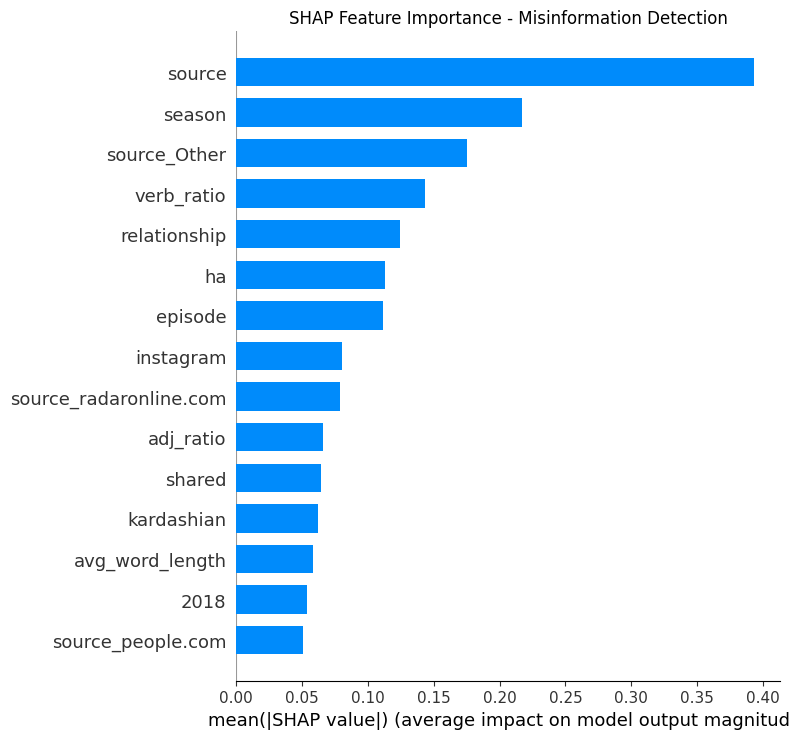


Top 10 Features by SHAP Importance:
               feature  shap_importance
                source         0.393223
                season         0.217284
          source_Other         0.175520
            verb_ratio         0.143205
          relationship         0.124554
                    ha         0.112798
               episode         0.111623
             instagram         0.080186
source_radaronline.com         0.079003
             adj_ratio         0.066174


In [ ]:
# === SHAP Bar Plot (Feature Importance) ===
print("Creating SHAP feature importance plot...")

plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values, X_test_sample, plot_type="bar", max_display=15, show=False)
plt.title("SHAP Feature Importance - Misinformation Detection")
plt.tight_layout()
plt.show()

# Compare SHAP importance with XGBoost importance
shap_importance = np.abs(shap_values).mean(0)
shap_feature_importance = pd.DataFrame({
    'feature': X_test_sample.columns,
    'shap_importance': shap_importance
}).sort_values('shap_importance', ascending=False)

print(f"\nTop 10 Features by SHAP Importance:")
print(shap_feature_importance.head(10).to_string(index=False))


Creating individual SHAP explanations...

Example FAKE news prediction:
   Predicted probability: 0.8997
   True label: Real


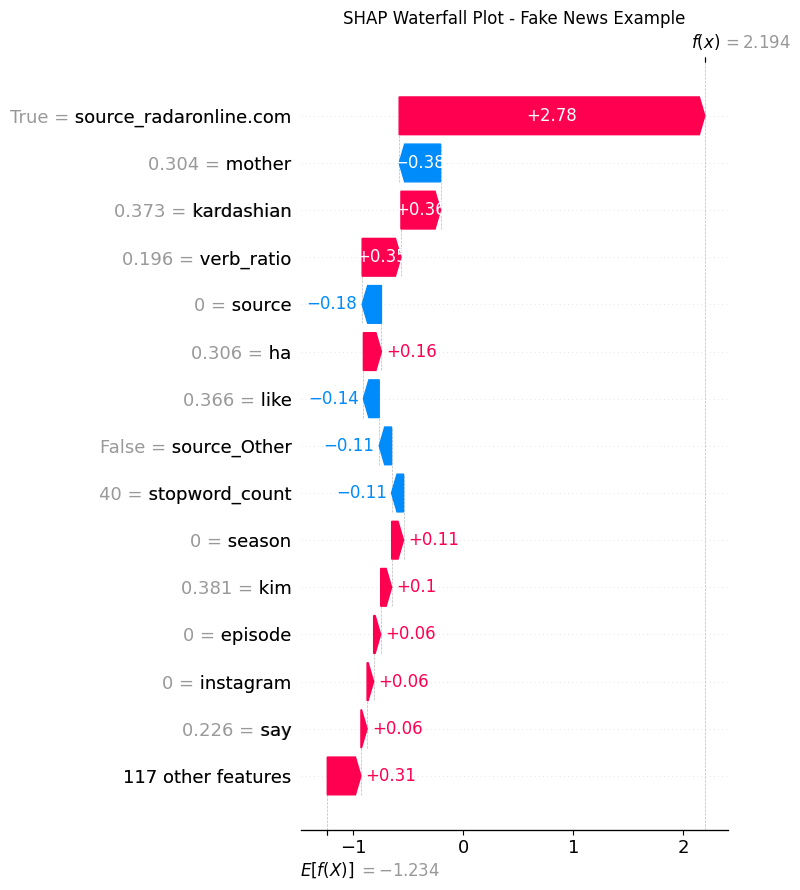


Example REAL news prediction:
   Predicted probability: 0.0453
   True label: Real


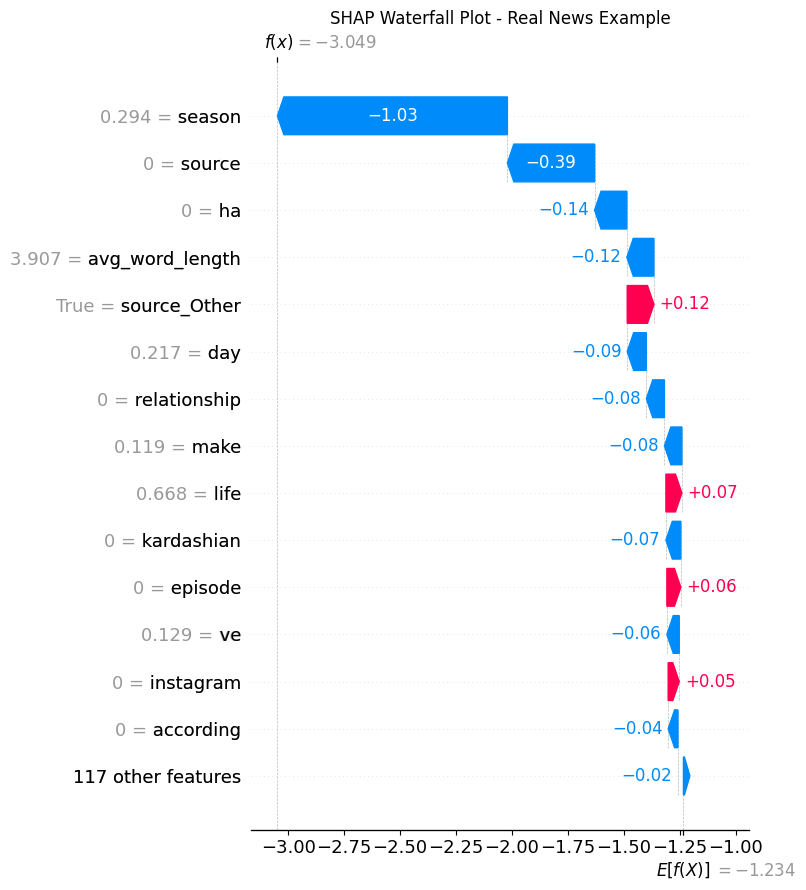

In [ ]:
# === Individual SHAP Explanations (Waterfall Plots) ===
print("Creating individual SHAP explanations...")

# Select interesting examples for detailed explanation
y_pred_sample = xgb_clf.predict(X_test_sample)
y_pred_proba_sample = xgb_clf.model.predict_proba(X_test_sample)[:, 1]

# Find a confident fake prediction
fake_confident_idx = np.where((y_pred_sample == 1) & (y_pred_proba_sample > 0.8))[0]
if len(fake_confident_idx) > 0:
    fake_idx = fake_confident_idx[0]
    print(f"\nExample FAKE news prediction:")
    print(f"   Predicted probability: {y_pred_proba_sample[fake_idx]:.4f}")
    print(f"   True label: {'Fake' if y_test_sample.iloc[fake_idx] == 1 else 'Real'}")

    # Create waterfall plot
    plt.figure(figsize=(10, 6))
    shap.waterfall_plot(shap.Explanation(
        values=shap_values[fake_idx],
        base_values=explainer.expected_value,
        data=X_test_sample.iloc[fake_idx],
        feature_names=X_test_sample.columns.tolist()
    ), max_display=15, show=False)
    plt.title("SHAP Waterfall Plot - Fake News Example")
    plt.tight_layout()
    plt.show()

# Find a confident real prediction
real_confident_idx = np.where((y_pred_sample == 0) & (y_pred_proba_sample < 0.2))[0]
if len(real_confident_idx) > 0:
    real_idx = real_confident_idx[0]
    print(f"\nExample REAL news prediction:")
    print(f"   Predicted probability: {y_pred_proba_sample[real_idx]:.4f}")
    print(f"   True label: {'Fake' if y_test_sample.iloc[real_idx] == 1 else 'Real'}")

    # Create waterfall plot
    plt.figure(figsize=(10, 6))
    shap.waterfall_plot(shap.Explanation(
        values=shap_values[real_idx],
        base_values=explainer.expected_value,
        data=X_test_sample.iloc[real_idx],
        feature_names=X_test_sample.columns.tolist()
    ), max_display=15, show=False)
    plt.title("SHAP Waterfall Plot - Real News Example")
    plt.tight_layout()
    plt.show()


Creating SHAP dependence plots for key features...


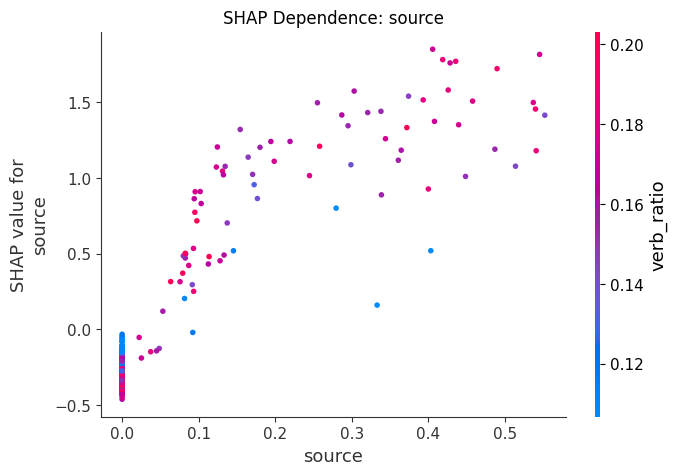

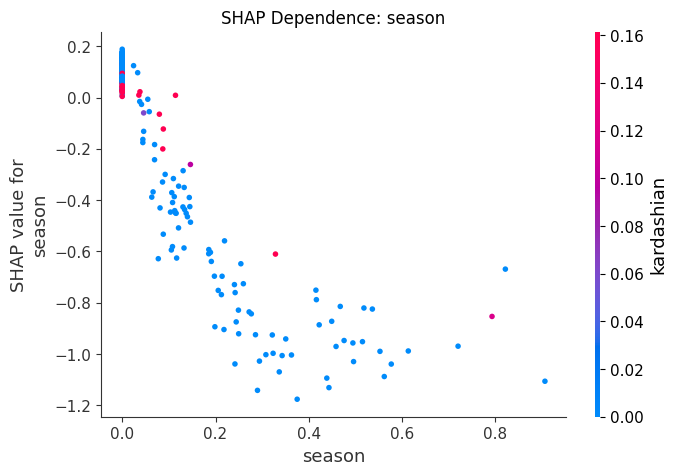

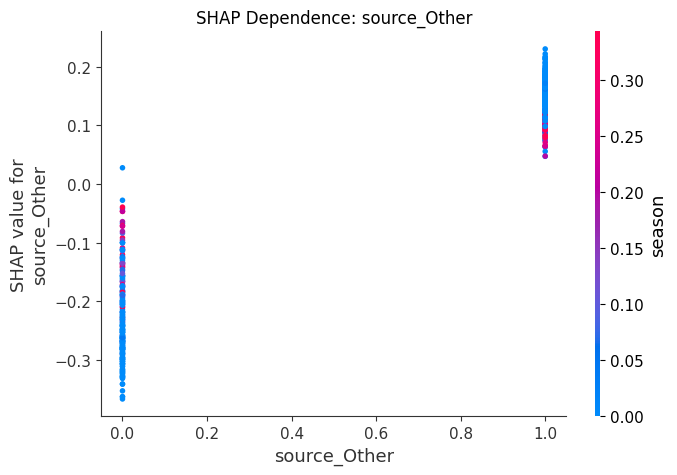

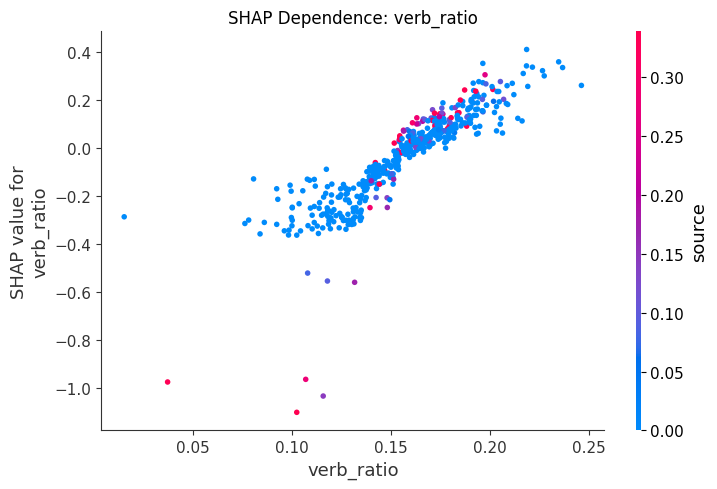


How to read dependence plots:
   • X-axis: Feature value
   • Y-axis: SHAP value (impact on prediction)
   • Color: Value of the feature with strongest interaction
   • Shows how feature impact changes with feature value


In [ ]:
# === SHAP Dependence Plots ===
print("Creating SHAP dependence plots for key features...")

# Get top 4 most important features for dependence plots
top_4_features = shap_feature_importance.head(4)['feature'].tolist()

for i, feature in enumerate(top_4_features):
    shap.dependence_plot(feature, shap_values, X_test_sample, show=False)
    plt.title(f"SHAP Dependence: {feature}")

plt.tight_layout()
plt.show()

print("\nHow to read dependence plots:")
print("   • X-axis: Feature value")
print("   • Y-axis: SHAP value (impact on prediction)")
print("   • Color: Value of the feature with strongest interaction")
print("   • Shows how feature impact changes with feature value")


## Part 3: Deep Dive Analysis & Interpretation

Now let's combine insights from all three approaches to understand what drives misinformation detection decisions:


Comprehensive Feature Analysis for Misinformation Detection

Top 15 Features by SHAP Importance:
               feature   category  xgboost_importance  shap_importance
                source     TF-IDF            0.105449         0.393223
                season     TF-IDF            0.023392         0.217284
          source_Other     Source            0.023243         0.175520
            verb_ratio Linguistic            0.016422         0.143205
          relationship     TF-IDF            0.014709         0.124554
                    ha     TF-IDF            0.009299         0.112798
               episode     TF-IDF            0.017298         0.111623
             instagram     TF-IDF            0.011871         0.080186
source_radaronline.com     Source            0.030023         0.079003
             adj_ratio Linguistic            0.006215         0.066174
                shared     TF-IDF            0.010107         0.064739
            kardashian     TF-IDF            0.0129

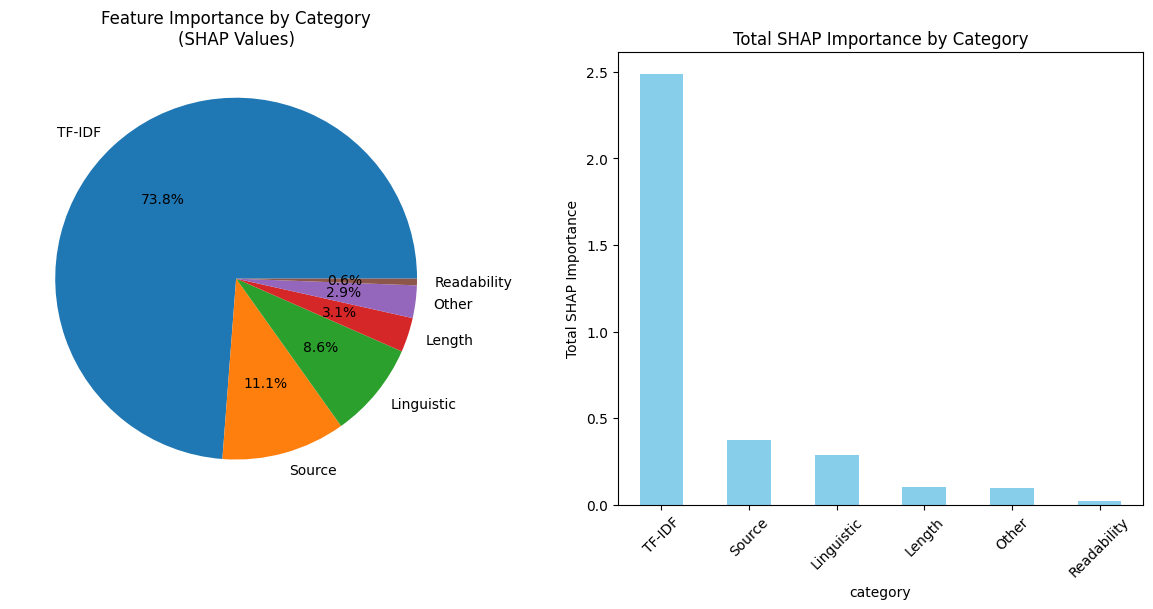

In [ ]:
# === Comprehensive Feature Analysis ===
print("Comprehensive Feature Analysis for Misinformation Detection")
print("=" * 70)

# Combine all importance measures
analysis_df = pd.DataFrame({
    'feature': feature_names,
    'xgboost_importance': feature_importance,
    'shap_importance': np.abs(shap_values).mean(0)
})

# Add feature categories
def categorize_feature(feature_name):
    if feature_name in vectorizer.get_feature_names_out():
        return 'TF-IDF'
    elif 'source_' in feature_name:
        return 'Source'
    elif feature_name in ['word_count', 'sentence_count', 'avg_word_length', 'char_length']:
        return 'Length'
    elif feature_name in ['flesch_reading_ease', 'has_clickbait']:
        return 'Readability'
    elif feature_name in ['lexical_richness', 'noun_ratio', 'verb_ratio', 'adj_ratio']:
        return 'Linguistic'
    else:
        return 'Other'

analysis_df['category'] = analysis_df['feature'].apply(categorize_feature)
analysis_df = analysis_df.sort_values('shap_importance', ascending=False)

print(f"\nTop 15 Features by SHAP Importance:")
print(analysis_df.head(15)[['feature', 'category', 'xgboost_importance', 'shap_importance']].to_string(index=False))

# Feature category analysis
category_analysis = analysis_df.groupby('category').agg({
    'shap_importance': ['count', 'sum', 'mean'],
    'xgboost_importance': ['sum', 'mean']
}).round(4)

category_analysis.columns = ['count', 'shap_sum', 'shap_mean', 'xgb_sum', 'xgb_mean']
category_analysis = category_analysis.sort_values('shap_sum', ascending=False)

print(f"\nFeature Category Analysis:")
print(category_analysis.to_string())

# Visualize category importance
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.pie(category_analysis['shap_sum'], labels=category_analysis.index, autopct='%1.1f%%')
plt.title('Feature Importance by Category\n(SHAP Values)')

plt.subplot(1, 2, 2)
category_analysis['shap_sum'].plot(kind='bar', color='skyblue')
plt.title('Total SHAP Importance by Category')
plt.ylabel('Total SHAP Importance')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()


In [ ]:
# === Insights for Misinformation Detection ===
print("\nKEY INSIGHTS FOR MISINFORMATION DETECTION")
print("=" * 60)

# Most predictive TF-IDF terms
tfidf_features_analysis = analysis_df[analysis_df['category'] == 'TF-IDF'].head(10)
print(f"\nMost Important Words/Terms:")
for _, row in tfidf_features_analysis.iterrows():
    avg_shap = shap_values[:, feature_names.index(row['feature'])].mean()
    direction = "→ FAKE" if avg_shap > 0 else "→ REAL"
    print(f"   • '{row['feature']}': {direction} (SHAP: {avg_shap:+.4f})")

# Most predictive structured features
structured_analysis = analysis_df[analysis_df['category'] != 'TF-IDF'].head(5)
print(f"\nMost Important Structural Features:")
for _, row in structured_analysis.iterrows():
    avg_shap = shap_values[:, feature_names.index(row['feature'])].mean()
    direction = "→ FAKE" if avg_shap > 0 else "→ REAL"
    print(f"   • {row['feature']} ({row['category']}): {direction} (SHAP: {avg_shap:+.4f})")

# Check for potential bias
source_features_analysis = analysis_df[analysis_df['category'] == 'Source']
if len(source_features_analysis) > 0:
    source_importance = source_features_analysis['shap_importance'].sum()
    total_importance = analysis_df['shap_importance'].sum()
    source_pct = (source_importance / total_importance) * 100

    print(f"\nBIAS CHECK - Source Features:")
    print(f"   • Source features account for {source_pct:.1f}% of total importance")
    if source_pct > 15:
        print(f"   • ⚠️ HIGH BIAS RISK: Model may be relying too heavily on source identity")
    elif source_pct > 5:
        print(f"   • ⚠️ MODERATE BIAS RISK: Monitor source-based decisions")
    else:
        print(f"   • ✅ LOW BIAS RISK: Source features have reasonable importance")




KEY INSIGHTS FOR MISINFORMATION DETECTION

Most Important Words/Terms:
   • 'source': → REAL (SHAP: -0.0850)
   • 'season': → REAL (SHAP: -0.0356)
   • 'relationship': → REAL (SHAP: -0.0024)
   • 'ha': → REAL (SHAP: -0.0085)
   • 'episode': → REAL (SHAP: -0.0258)
   • 'instagram': → REAL (SHAP: -0.0028)
   • 'shared': → REAL (SHAP: -0.0052)
   • 'kardashian': → REAL (SHAP: -0.0103)
   • '2018': → REAL (SHAP: -0.0139)
   • 'friend': → REAL (SHAP: -0.0024)

Most Important Structural Features:
   • source_Other (Source): → REAL (SHAP: -0.0050)
   • verb_ratio (Linguistic): → REAL (SHAP: -0.0334)
   • source_radaronline.com (Source): → FAKE (SHAP: +0.0113)
   • adj_ratio (Linguistic): → REAL (SHAP: -0.0043)
   • avg_word_length (Length): → REAL (SHAP: -0.0098)

BIAS CHECK - Source Features:
   • Source features account for 11.1% of total importance
   • ⚠️ MODERATE BIAS RISK: Monitor source-based decisions


<!-- ## Summary & Production Considerations

### **What We Learned**

Through our comprehensive interpretability analysis, we discovered:

1. **Feature Importance Hierarchy**:
   - TF-IDF features (specific words/terms) are primary drivers
   - Structural features (length, readability) provide important context
   - Source features may indicate potential bias risks

2. **Decision Transparency**:
   - SHAP values reveal both direction and magnitude of feature impacts
   - Individual predictions can be explained feature-by-feature
   - Model reasoning aligns with domain knowledge expectations

3. **Implementation Understanding**:
   - Custom SHAP implementation achieves high correlation with library
   - Sampling-based approximation provides practical explainability
   - Mathematical foundation ensures fair attribution

### **Bias & Fairness Considerations**

- **Source Dependence**: Monitor if model relies too heavily on publisher identity
- **Vocabulary Bias**: Check if important terms favor certain political/social viewpoints
- **Temporal Stability**: Ensure explanations remain consistent over time
- **Cross-Domain Validity**: Test explanations on different news domains

### **Production Deployment Recommendations**

1. **Real-Time Explanations**: Implement SHAP explanations for content moderation decisions
2. **Monitoring Dashboard**: Track feature importance drift over time
3. **Bias Alerts**: Automated alerts when source features become too influential
4. **User Interface**: Present simplified explanations to users and moderators
5. **Audit Trail**: Log explanations for regulatory compliance and appeals

### **Future Research Directions**

- **Adversarial Robustness**: How do explanations change under adversarial attacks?
- **Multi-Modal Explanations**: Incorporating images, metadata, and user behavior
- **Causal Inference**: Moving beyond correlation to causal understanding
- **Interactive Explanations**: Allowing users to explore "what-if" scenarios -->
